In [ ]:
#Etapa01
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import squarify
import numpy as np

# permitir emojis no Windows (opcional)
plt.rcParams['font.family'] = 'Segoe UI Emoji'

In [ ]:
#Etapa02
pasta = r"../EcommerceOlist/olist"

In [ ]:
#Etapa03
print("Pasta existe?", os.path.exists(pasta))

Pasta existe? True


In [ ]:
# Etapa04

files = {
    "categories": "olist/product_category_name_translation.csv",
    "customers": "olist/olist_customers_dataset.csv",
    "sellers": "olist/olist_sellers_dataset.csv",
    "order_items": "olist/olist_order_items_dataset.csv",
    "products": "olist/olist_products_dataset.csv",
    "orders": "olist/olist_orders_dataset.csv",
    "payments": "olist/olist_order_payments_dataset.csv",
    "geolocation": "olist/olist_geolocation_dataset.csv",
    "reviews": "olist/olist_order_reviews_dataset.csv"
}


categories = pd.read_csv(files["categories"])
customers = pd.read_csv(files["customers"])
sellers = pd.read_csv(files["sellers"])
order_items = pd.read_csv(files["order_items"])
products = pd.read_csv(files["products"])
orders = pd.read_csv(files["orders"])
payments = pd.read_csv(files["payments"])
geolocation = pd.read_csv(files["geolocation"])
reviews = pd.read_csv(files["reviews"])

print("Bases carregadas com sucesso!")


Bases carregadas com sucesso!



Top 10 estados com mais vendedores:
  Estado  Qtd_Vendedores  Percentual
0     SP            1849       60.74
1     PR             349       11.47
2     MG             244        8.02
3     SC             190        6.24
4     RJ             171        5.62
5     RS             129        4.24
6     GO              40        1.31
7     DF              30        0.99
8     ES              23        0.76
9     BA              19        0.62


C:\Users\Wanderson\AppData\Local\Temp\ipykernel_13732\1525834716.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


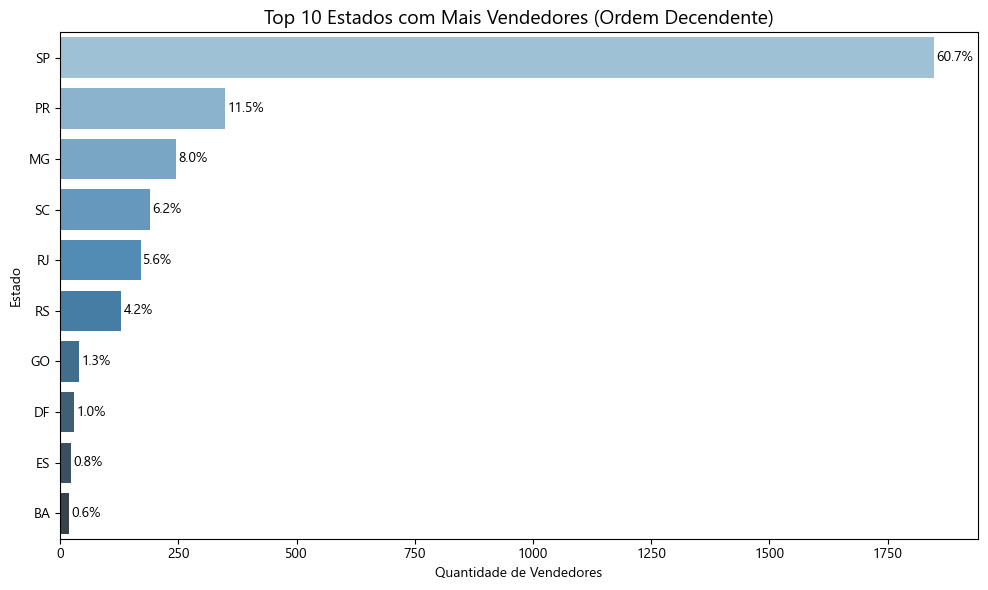

In [ ]:
#Etapa05

# Contagem por estado (10 maiores)
vendedores_por_estado = (
    sellers["seller_state"]
    .value_counts()
    .head(10)
    .reset_index()
)

vendedores_por_estado.columns = ["Estado", "Qtd_Vendedores"]

# Calcular participação percentual
total_top10 = vendedores_por_estado["Qtd_Vendedores"].sum()
vendedores_por_estado["Percentual"] = (
    vendedores_por_estado["Qtd_Vendedores"] / total_top10 * 100
).round(2)

# Mostrar tabela
print("\nTop 10 estados com mais vendedores:")
print(vendedores_por_estado)

# Gráfico horizontal DESCENDENTE
plt.figure(figsize=(10,6))
sns.barplot(
    data=vendedores_por_estado.sort_values("Qtd_Vendedores", ascending=False), 
    x="Qtd_Vendedores",
    y="Estado",
    palette="Blues_d"
)

plt.title("Top 10 Estados com Mais Vendedores (Ordem Decendente)", fontsize=14)
plt.xlabel("Quantidade de Vendedores")
plt.ylabel("Estado")

# Adicionar percentuais nas barras
dados_ordenados = vendedores_por_estado.sort_values("Qtd_Vendedores", ascending=False)

for i, (valor, pct) in enumerate(zip(dados_ordenados["Qtd_Vendedores"], dados_ordenados["Percentual"])):
    plt.text(valor + 5, i, f"{pct:.1f}%", va='center')

plt.tight_layout()
plt.show()




Top 10 categorias mais vendidas:
               Categoria  Quantidade
0         bed_bath_table       11115
1          health_beauty        9670
2         sports_leisure        8641
3        furniture_decor        8334
4  computers_accessories        7827
5             housewares        6964
6          watches_gifts        5991
7              telephony        4545
8           garden_tools        4347
9                   auto        4235


C:\Users\Wanderson\AppData\Local\Temp\ipykernel_13732\1888197598.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_categorias, y="Categoria", x="Quantidade", palette="viridis")


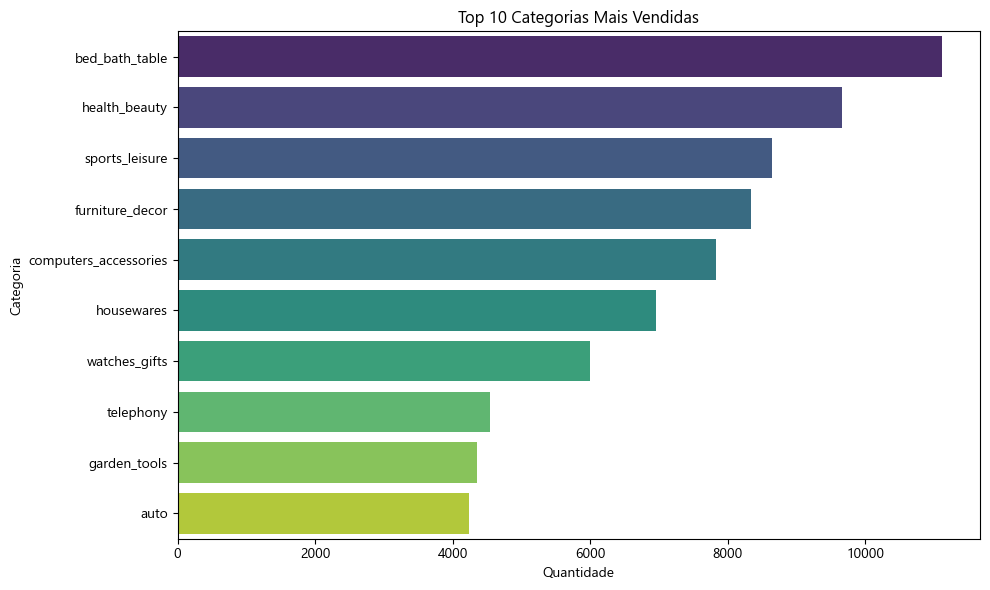

In [ ]:
#Etapa06

# Juntar itens com produtos
itens_produtos = order_items.merge(products, on="product_id", how="left")

# Juntar com categorias traduzidas
itens_produtos = itens_produtos.merge(categories, on="product_category_name", how="left")

top_categorias = (
    itens_produtos["product_category_name_english"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_categorias.columns = ["Categoria", "Quantidade"]

print("\nTop 10 categorias mais vendidas:")
print(top_categorias)

# Gráfico
plt.figure(figsize=(10,6))
sns.barplot(data=top_categorias, y="Categoria", x="Quantidade", palette="viridis")
plt.title("Top 10 Categorias Mais Vendidas")
plt.xlabel("Quantidade")
plt.ylabel("Categoria")
plt.tight_layout()
plt.show()


C:\Users\Wanderson\AppData\Local\Temp\ipykernel_13732\958707933.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_entregas["atraso"] = df_entregas["tempo_real_entrega"] - df_entregas["tempo_estimado_entrega"]



Média de atraso (dias):
-11.280142211534475


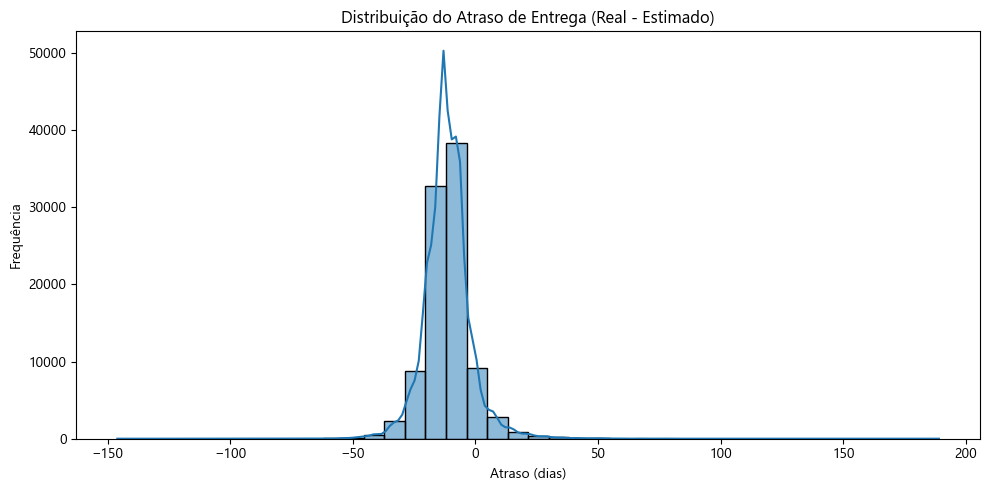

In [ ]:
#Etapa07

orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])

# Calcular tempos
orders["tempo_real_entrega"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

orders["tempo_estimado_entrega"] = (
    orders["order_estimated_delivery_date"] - orders["order_purchase_timestamp"]
).dt.days

# Remover valores faltantes
df_entregas = orders.dropna(subset=["tempo_real_entrega", "tempo_estimado_entrega"])

# Diferença entre real e estimado
df_entregas["atraso"] = df_entregas["tempo_real_entrega"] - df_entregas["tempo_estimado_entrega"]

print("\nMédia de atraso (dias):")
print(df_entregas["atraso"].mean())

# Gráfico: distribuição de atraso
plt.figure(figsize=(10,5))
sns.histplot(df_entregas["atraso"], bins=40, kde=True)
plt.title("Distribuição do Atraso de Entrega (Real - Estimado)")
plt.xlabel("Atraso (dias)")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()


df_preco construído com 112650 registros.
Quantil 95% do preço (usado para limitar eixos): R$ 349.90


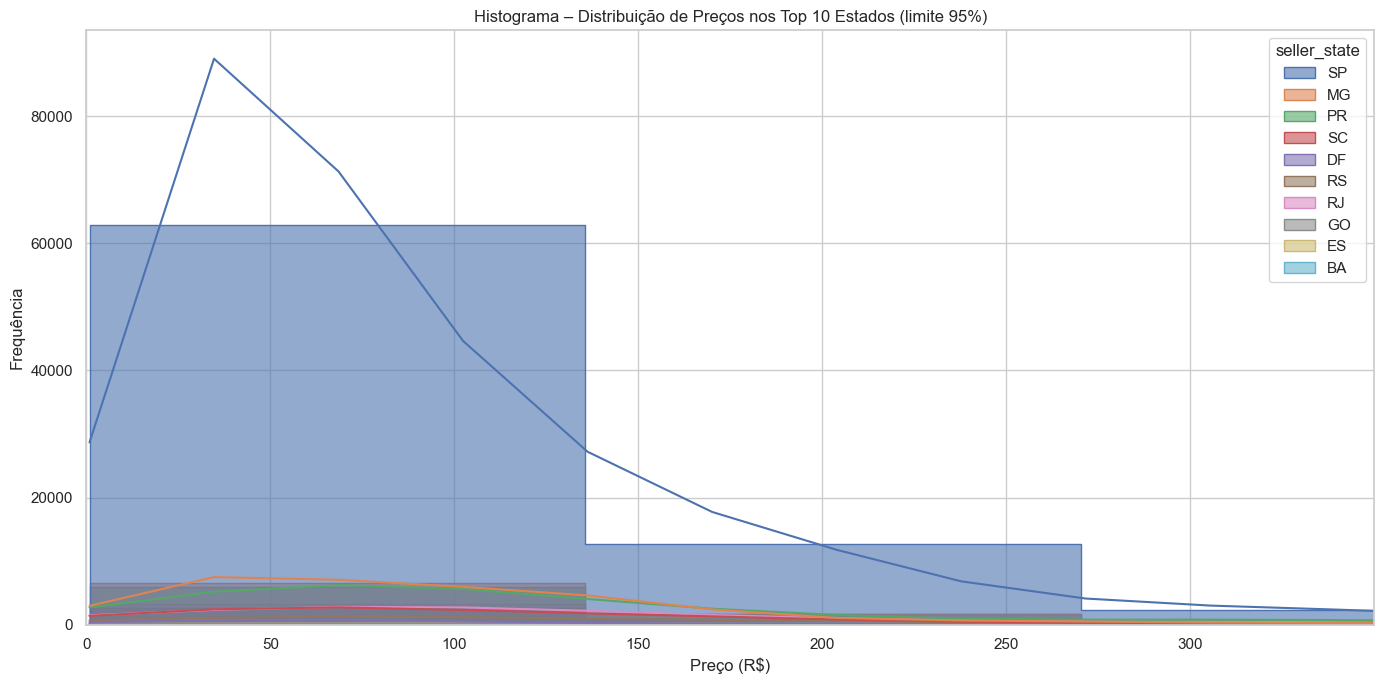

C:\Users\Wanderson\AppData\Local\Temp\ipykernel_13732\1174020303.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


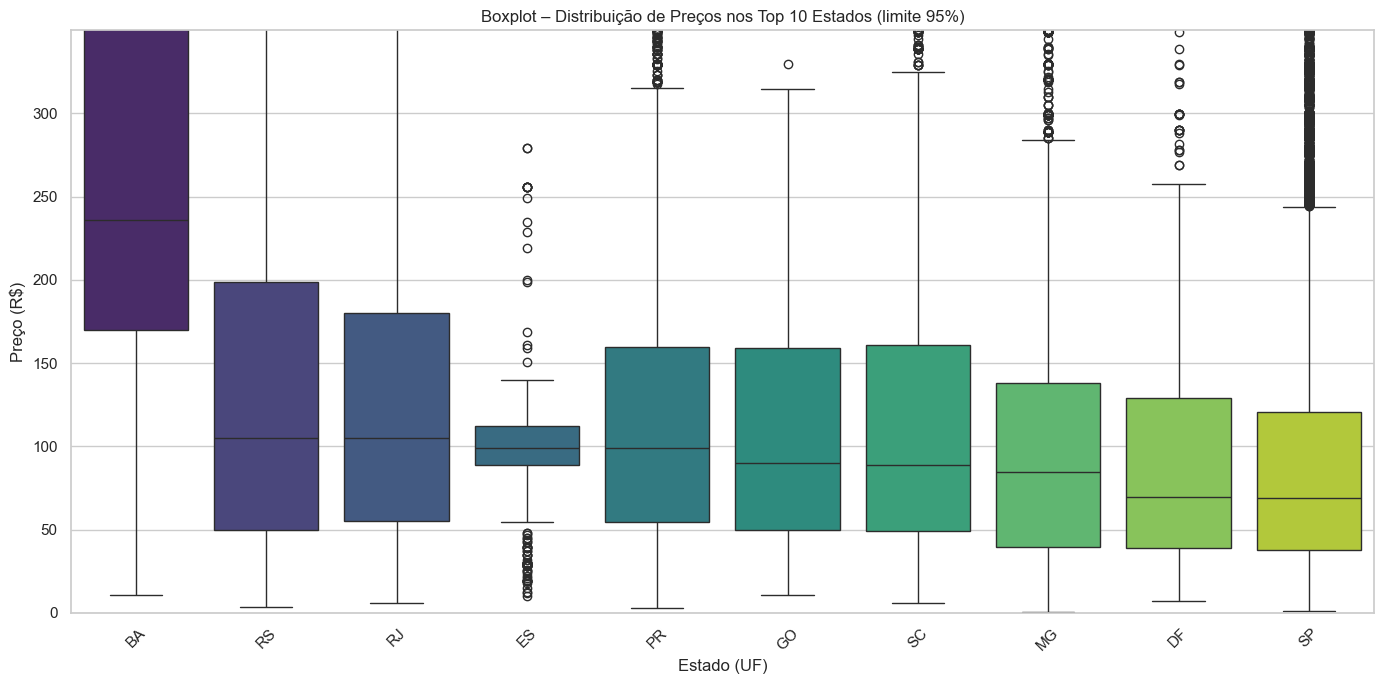


Resumo de preços por estado (top 10):
  seller_state  count        mean  median         std      q25      q75  \
0           BA    643  444.108180   235.9  470.091163  170.000  599.000   
6           RJ   4818  175.173147   105.0  270.828087   54.990  179.990   
7           RS   2199  172.150769   105.0  216.929823   50.000  199.000   
8           SC   4075  155.196582    89.0  216.428364   48.945  160.900   
5           PR   8671  145.529606    98.9  202.294163   54.900  159.900   
2           ES    372  128.197876    99.0  173.387461   89.000  112.000   
3           GO    520  127.690788    89.9  314.801124   49.900  158.900   
4           MG   8827  114.598928    84.9  142.280044   39.900  137.900   
9           SP  80342  108.951684    69.0  166.095223   37.990  120.415   
1           DF    899  108.731346    69.9  122.066527   38.890  129.000   

         q95  
0  1433.2900  
6   586.3025  
7   598.8100  
8   539.9000  
5   410.0000  
2   278.9900  
3   250.0855  
4   321.0000  


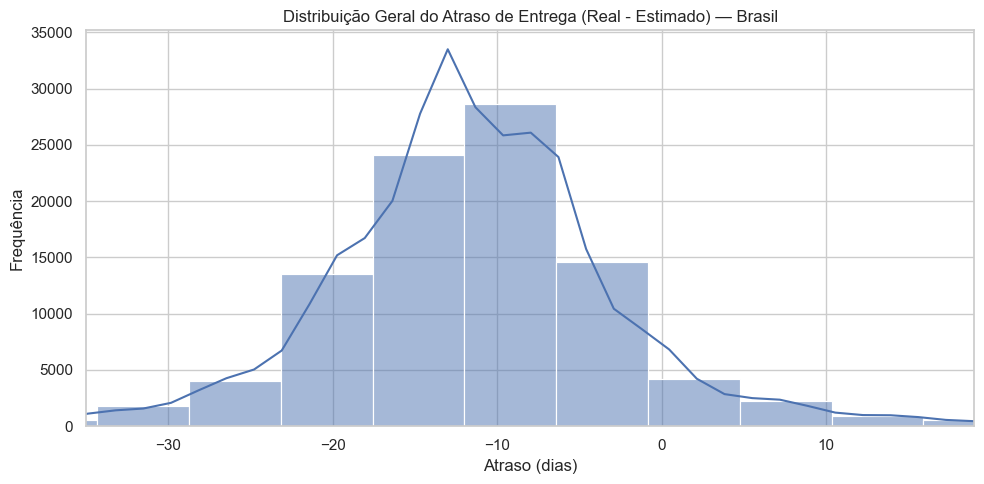

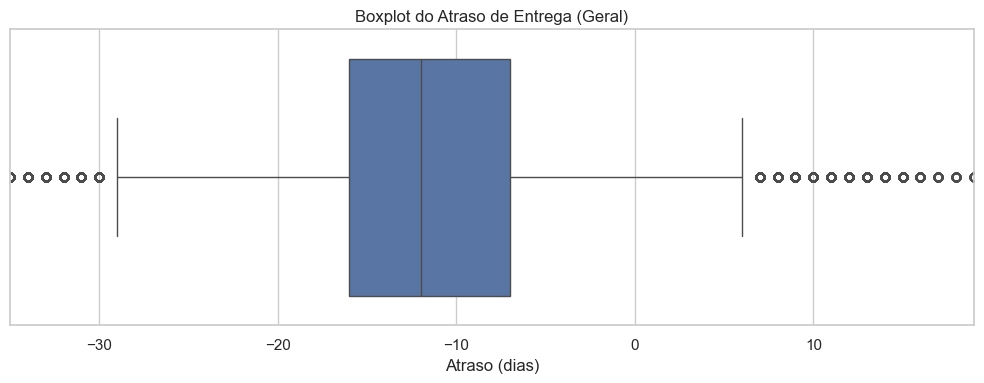

In [ ]:
#Etapa08

# Célula única: reconstrói df_preco se necessário, plota histogram/boxplot (top10 estados)
# e executa ETAPA 4 — validação geral do tempo real vs estimado de entrega.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")

# ---------- 1) Verificações básicas ----------
required_vars = ["order_items", "sellers", "products", "orders"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(f"As seguintes variáveis não foram encontradas no ambiente: {missing}. Carregue-as antes de executar esta célula.")

# checar colunas essenciais
if "seller_id" not in sellers.columns or "seller_state" not in sellers.columns:
    raise KeyError("Tabela 'sellers' deve conter as colunas 'seller_id' e 'seller_state'.")
if "product_id" not in order_items.columns or "seller_id" not in order_items.columns:
    raise KeyError("Tabela 'order_items' deve conter as colunas 'product_id' e 'seller_id'.")
if ("price" not in order_items.columns) and ("price" not in products.columns):
    raise KeyError("Coluna 'price' não encontrada em 'order_items' nem em 'products'.")

# ---------- 2) Construção/validação de df_preco ----------
if 'df_preco' not in globals() or not isinstance(globals()['df_preco'], pd.DataFrame):
    # preferir preço em order_items, senão puxar de products
    if "price" in order_items.columns:
        df_tmp = order_items.copy()
    else:
        # garantir que products tenha product_id e price
        if "product_id" not in products.columns or "price" not in products.columns:
            raise KeyError("Para obter preço a partir de 'products' é necessário 'product_id' e 'price' em products.")
        df_tmp = order_items.merge(products[["product_id", "price"]], on="product_id", how="left")
    # merge com sellers para estado
    df_preco = df_tmp.merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left")
    # manter apenas price e seller_state
    df_preco = df_preco[["price", "seller_state"]].dropna(subset=["price"])
    print(f"df_preco construído com {len(df_preco)} registros.")
else:
    print("df_preco já existe no ambiente. Verificando colunas...")
    if not {"price","seller_state"}.issubset(df_preco.columns):
        raise KeyError("df_preco existe mas não contém as colunas 'price' e 'seller_state' necessárias.")
    print(f"df_preco OK com {len(df_preco)} registros.")

# converter price para numérico seguro
df_preco["price"] = pd.to_numeric(df_preco["price"], errors="coerce")
df_preco = df_preco.dropna(subset=["price"])
if df_preco.empty:
    raise ValueError("df_preco ficou vazio após conversão do preço para numérico.")

# ---------- 3) Preparar dados para plot (Top 10 estados por vendedor) ----------
top10_estados = sellers["seller_state"].value_counts().head(10).index.tolist()
df_plot = df_preco[df_preco["seller_state"].isin(top10_estados)].copy()

if df_plot.empty:
    raise ValueError("Nenhum registro em df_plot após filtrar pelos top 10 estados. Verifique dados de sellers/order_items.")

q95 = df_plot["price"].quantile(0.95)
print(f"Quantil 95% do preço (usado para limitar eixos): R$ {q95:.2f}")

# ---------- 4) Histograma (preços) ----------
plt.figure(figsize=(14,7))
sns.histplot(
    data=df_plot,
    x="price",
    hue="seller_state",
    bins=50,
    kde=True,
    element="step",
    alpha=0.6
)
plt.title("Histograma – Distribuição de Preços nos Top 10 Estados (limite 95%)")
plt.xlabel("Preço (R$)")
plt.ylabel("Frequência")
plt.xlim(left=0, right=float(q95))
plt.tight_layout()
plt.show()

# ---------- 5) Boxplot (preços por estado) ----------
plt.figure(figsize=(14,7))
order_states = df_plot.groupby("seller_state")["price"].median().sort_values(ascending=False).index.tolist()
sns.boxplot(
    data=df_plot,
    x="seller_state",
    y="price",
    order=order_states,
    palette="viridis"
)
plt.title("Boxplot – Distribuição de Preços nos Top 10 Estados (limite 95%)")
plt.xlabel("Estado (UF)")
plt.ylabel("Preço (R$)")
plt.ylim(0, float(q95))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------- 6) Estatística resumo por estado (opcional) ----------
summary_by_state = df_plot.groupby("seller_state")["price"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
    q95=lambda x: x.quantile(0.95)
).reset_index().sort_values("mean", ascending=False)
print("\nResumo de preços por estado (top 10):")
print(summary_by_state)

# ---------- 7) ETAPA 4 — VALIDAÇÃO GERAL (tempo real x estimado) ----------
# Verificações e conversões de colunas em orders
for col in ["order_purchase_timestamp","order_estimated_delivery_date","order_delivered_customer_date"]:
    if col not in orders.columns:
        raise KeyError(f"Coluna '{col}' não encontrada em 'orders'.")

orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], errors="coerce")
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"], errors="coerce")
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"], errors="coerce")

df_entregas_geral = orders.dropna(subset=["order_purchase_timestamp","order_estimated_delivery_date","order_delivered_customer_date"]).copy()
if df_entregas_geral.empty:
    raise ValueError("Nenhum registro em orders com as três datas preenchidas. Não é possível calcular tempos de entrega.")

df_entregas_geral["tempo_real_entrega"] = (df_entregas_geral["order_delivered_customer_date"] - df_entregas_geral["order_purchase_timestamp"]).dt.days
df_entregas_geral["tempo_estimado_entrega"] = (df_entregas_geral["order_estimated_delivery_date"] - df_entregas_geral["order_purchase_timestamp"]).dt.days
df_entregas_geral["atraso"] = df_entregas_geral["tempo_real_entrega"] - df_entregas_geral["tempo_estimado_entrega"]

# Estatísticas
total = len(df_entregas_geral)
mean_real = df_entregas_geral["tempo_real_entrega"].mean()
mean_est = df_entregas_geral["tempo_estimado_entrega"].mean()
mean_atraso = df_entregas_geral["atraso"].mean()
median_atraso = df_entregas_geral["atraso"].median()
std_atraso = df_entregas_geral["atraso"].std()

print("\n===== VALIDAÇÃO GERAL — TEMPOS DE ENTREGA =====")
print(f"Total de pedidos analisados: {total}")
print(f"Média do tempo real (dias): {mean_real:.2f}")
print(f"Média do tempo estimado (dias): {mean_est:.2f}")
print(f"Média do atraso (dias): {mean_atraso:.2f}")
print(f"Mediana do atraso (dias): {median_atraso:.2f}")
print(f"Desvio padrão do atraso: {std_atraso:.2f}")
print("==============================================\n")

# Histograma do atraso (limitar x para visualização usando percentis)
p_low, p_high = np.percentile(df_entregas_geral["atraso"].dropna(), [1, 99])
plt.figure(figsize=(10,5))
sns.histplot(df_entregas_geral["atraso"], bins=60, kde=True)
plt.title("Distribuição Geral do Atraso de Entrega (Real - Estimado) — Brasil")
plt.xlabel("Atraso (dias)")
plt.ylabel("Frequência")
plt.xlim(p_low, p_high)
plt.tight_layout()
plt.show()

# Boxplot do atraso (mostra outliers)
plt.figure(figsize=(10,4))
sns.boxplot(x=df_entregas_geral["atraso"])
plt.title("Boxplot do Atraso de Entrega (Geral)")
plt.xlabel("Atraso (dias)")
plt.xlim(p_low, p_high)
plt.tight_layout()
plt.show()
